# Vannila Policy Gradien

It is the simplest Policy Gradient Method it is a on-policy method that works by maximazing:

$
\mathbb{E}[log\pi_\theta(a_t|s_t) \times G_t]
$

We start creating the MLP responsible for being the function approximator for the policy $\pi_\theta$. 


In [1]:
from pg_env import *

In [2]:
def compute_discounted_returns(rewards: Sequence[float], gamma: float) -> Tensor:
    """
    Compute rewards-to-go:
        G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...

    Returns a 1D float32 tensor of shape [T].
    """
    returns: List[float] = []
    running_return = 0.0

    for reward in reversed(rewards):
        running_return = reward + gamma * running_return
        returns.append(running_return)

    returns.reverse()
    out = torch.tensor(returns, dtype=torch.float32)

    # Normalization is not mathematically required, but often helps reduce variance.
    if len(out) > 1:
        out = (out - out.mean()) / (out.std() + 1e-8)

    return out

In [3]:
class ReinforceAgent:
    """
    Vanilla REINFORCE agent for discrete action spaces.

    This agent owns:
    - a policy network
    - an optimizer
    - the REINFORCE update rule

    It does NOT own the environment.
    """
    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        learning_rate: float = 1e-2,
        gamma: float = 0.99,
        device: Optional[torch.device] = None,
    ) -> None:
        self.device = device or torch.device("cpu")
        self.gamma = gamma

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=learning_rate)

    def distribution(self, obs: np.ndarray) -> Categorical:
        """
        Build the action distribution for a single observation.
        """
        obs_tensor = to_tensor(obs, self.device)
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> Tuple[int, Tensor]:
        """
        Sample an action from the current policy and return:
        - action as Python int
        - log probability tensor for that sampled action
        """
        dist = self.distribution(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return int(action.item()), log_prob

    def predict_action(self, obs: np.ndarray) -> int:
        """
        Greedy action selection for evaluation:
        choose argmax over policy probabilities.
        """
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            action = torch.argmax(logits, dim=-1)
            return int(action.item())

    def update_from_episode(self, episode: EpisodeBatch) -> float:
        """
        Apply one REINFORCE update using a single collected episode.
        """
        returns = compute_discounted_returns(episode.rewards, gamma=self.gamma).to(self.device)
        log_probs = torch.cat(episode.log_probs, dim=0)

        # REINFORCE loss:
        # maximize sum_t log pi(a_t | s_t) * G_t
        # so with gradient descent we minimize the negative.
        loss = -(log_probs * returns).sum()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return float(loss.item())

Starts defining the Enviroment structures

Then we define the advantage function, which in this case is just the discounted normalized rewards over time.

In [4]:
def build_reinforce_agent_from_env(
    env_fn: EnvFn,
    hidden_sizes: Sequence[int] = (64, 64),
    learning_rate: float = 1e-2,
    gamma: float = 0.99,
    device: Optional[torch.device] = None,
) -> ReinforceAgent:
    """
    Inspect one environment instance to infer observation and action sizes,
    then construct a compatible REINFORCE agent.
    """
    env = env_fn()

    assert isinstance(env.observation_space, gym.spaces.Box), "Expected Box observation space."
    assert isinstance(env.action_space, gym.spaces.Discrete), "Expected Discrete action space."

    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return ReinforceAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        learning_rate=learning_rate,
        gamma=gamma,
        device=device,
    )

[episode    1] train_return=   9.00 | loss=  -0.2417 | eval_mean_return=   9.50
[episode   25] train_return=   9.00 | loss=   0.3859 | eval_mean_return=   9.30
[episode   50] train_return=  22.00 | loss=   0.2901 | eval_mean_return=   9.50
[episode   75] train_return=  15.00 | loss=   0.4757 | eval_mean_return=   9.40
[episode  100] train_return=  40.00 | loss=   0.5077 | eval_mean_return=   9.40
[episode  125] train_return=  10.00 | loss=  -0.3308 | eval_mean_return=   8.80
[episode  150] train_return=  22.00 | loss=  -0.0089 | eval_mean_return=   9.20
[episode  175] train_return=  20.00 | loss=  -0.2482 | eval_mean_return=   9.60
[episode  200] train_return=  24.00 | loss=  -0.1296 | eval_mean_return=   9.30
[episode  225] train_return=  11.00 | loss=   0.2504 | eval_mean_return=  12.00
[episode  250] train_return=  51.00 | loss=   0.4361 | eval_mean_return=  48.80
[episode  275] train_return=  25.00 | loss=  -1.0245 | eval_mean_return=  80.60
[episode  300] train_return=  13.00 | lo

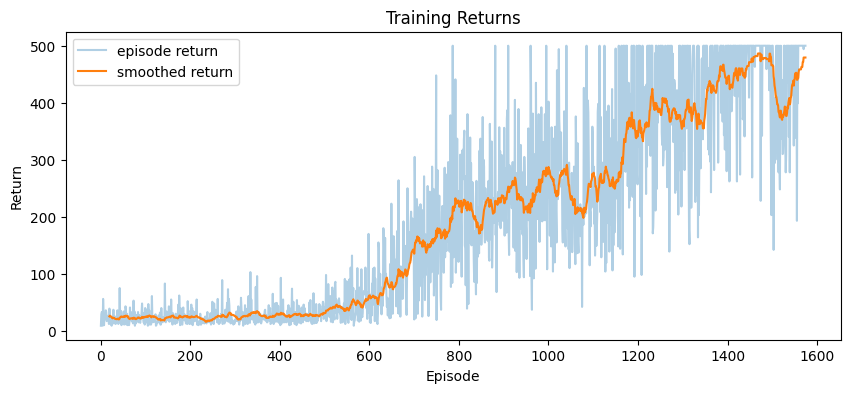

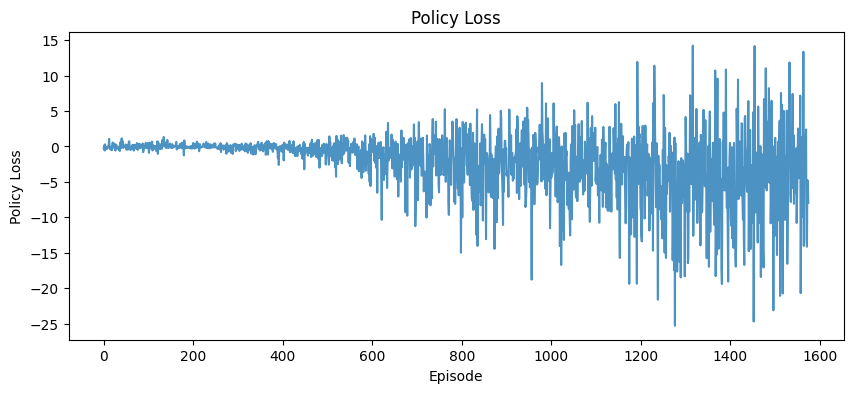

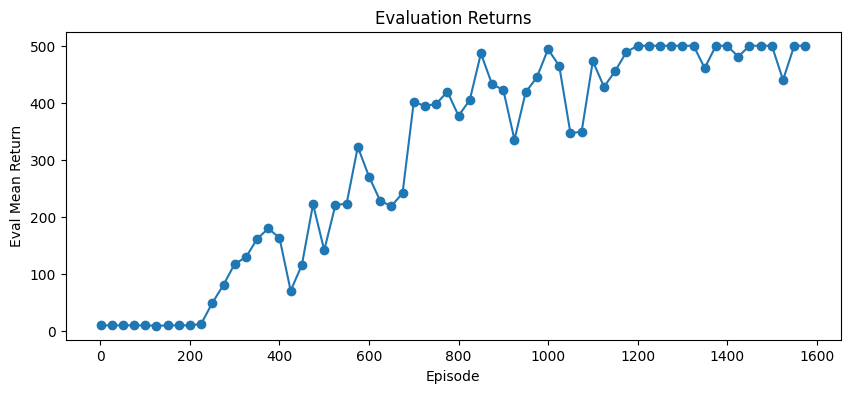

Stopped at episode 1575: no eval improvement greater than 5.00 for 15 evals


In [24]:
set_seed(42)

env_fn: EnvFn = lambda: make_cartpole_env(render_mode=None)

agent = build_reinforce_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(32, 32),
    learning_rate=3e-4,
    gamma=0.99,
)

history = train_on_policy_agent(
    env_fn=env_fn,
    agent=agent,
    num_episodes=10000,
    eval_every=25,
    eval_episodes=10,
    early_stopping=EarlyStoppingConfig(
        patience_evals=15,
        min_delta=5.0,
    ),
    verbose=True,
)

plot_training_history(history)

if history.stopped_early:
    print(f"Stopped at episode {history.stop_episode}: {history.stop_reason}")

In [25]:
visual_env:EnvFn = lambda: make_cartpole_env(render_mode='human')

run_demo_episode(visual_env, agent, greedy=True)

Demo return: 500.00


500.0